In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import rdkit
from rdkit import Chem

import skfp 
from skfp.fingerprints import AtomPairFingerprint, PubChemFingerprint, EStateFingerprint, ECFPFingerprint, MACCSFingerprint, ERGFingerprint
from splito._scaffold_split import ScaffoldSplit

import rdkit
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Descriptors
from rdkit import RDLogger

import datamol as dm

import tqdm
from tqdm.notebook import tqdm

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import ParameterGrid
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, matthews_corrcoef, f1_score, confusion_matrix
from sklearn.model_selection import cross_validate , RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier  


import shap

import xgboost as xgb
import catboost as cb
import lightgbm as lgb

import random
import sklearn
RDLogger.DisableLog('rdApp.warning')

In [2]:

drop_smile = 'C[C@H](CC[C@](C)(O)C(F)(F)F)[C@H]1CC[C@H]2[C@@H]3CC=C4C[C@@](C)(O)CC[C@]4(C)[C@H]3CC[C@]12C'

feature_diff = ['molecule_chembl_id', 'smiles', 'standard_value', 'class',	'pic50', 'scaffold', 'EF', 'scaffold_count']

TARGET_COL = 'target'
BIO_CLASS = 'class'
DATASET_COL = 'dataset'
NAME_COL = 'molecule_chembl_id'
all_feature = pd.read_csv('../all_feature_train.csv')
all_feature = all_feature[~(all_feature['smiles']==drop_smile)]
all_feature.reset_index(drop=True, inplace=True)

In [3]:
def Bioactivity_class(value):

    if value <= 7500:
        return 'active'
    else:
        return 'inactive'

all_feature['class'] = all_feature['standard_value'].apply(Bioactivity_class)

print(all_feature['class'].value_counts())

class
inactive    1136
active       565
Name: count, dtype: int64


In [4]:
all_feature['scaffold'] = all_feature['smiles'].apply(lambda x : MurckoScaffold.MurckoScaffoldSmiles(smiles=x))

total_molecules = len(all_feature)
total_active = len(all_feature[all_feature['class'].isin(['active', 'potent'])])
p_active_total = total_active / total_molecules

# ۲. تابع محاسبه EF و تعداد مولکول‌ها برای هر اسکافولد
def calc_ef(group):
    n_scaffold = len(group)
    n_active_scaffold = len(group[group['class'].isin(['active', 'potent'])])
    p_active_scaffold = n_active_scaffold / n_scaffold if n_scaffold > 0 else 0
    ef = p_active_scaffold / p_active_total if p_active_total > 0 else 0
    return pd.Series({'EF': ef, 'scaffold_count': n_scaffold})

ef_df = all_feature.groupby('scaffold').apply(calc_ef).reset_index()
all_feature = all_feature.merge(ef_df, on='scaffold', how='left')

C:\Users\az592\AppData\Local\Temp\ipykernel_1744\1332472869.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ef_df = all_feature.groupby('scaffold').apply(calc_ef).reset_index()


In [5]:
all_feature = all_feature[~((all_feature['scaffold_count'] > 10) & (all_feature['EF'] < 0.5))]
all_feature = all_feature[~((all_feature['scaffold_count'] > 5) & (all_feature['EF'] == 0))]

all_feature.reset_index(drop=True, inplace=True)

In [7]:
target_col = 'stage'
Name = 'molecule_chembl_id'

In [19]:
df_nonstr = pd.concat([f_dataset[['molecule_chembl_id', 'smiles', 'class']], f_dataset.filter(regex='rdkit_|mord')], axis=1)
df_str = pd.concat([f_dataset[['molecule_chembl_id', 'smiles', 'class']], f_dataset.filter(regex='rdkitfin|ecfp|pubch|maccs')], axis=1)

## df_stracture 

In [20]:
diff_feature = ['molecule_chembl_id', 'smiles', 'class']
featur_filter_str = filter_features(df_str, diff_feature, variance_threshold=0.01, correlation_threshold=0.75)

In [23]:
feat_name = featur_filter_str.columns.to_list()

In [26]:
with open('fingerprint_423.txt', 'w', encoding='utf-8') as f:
    for item in feat_name:
        f.write(str(item) + '\n')

In [22]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# ======================
# Data Preparation
# ======================
# Assuming:
# - df_combine: Combined dataset (1502 training + 117k screening)
# - my_list: List of relevant feature columns
# - y_train: Training labels

train_df = featur_filter_str  # Training data

# ======================
# Identify Column Types
# ======================
# Non-binary columns (training data only)
non_binary_columns = [
    col for col in train_df.columns
    if train_df[col].nunique() > 2 
]

# Columns requiring special handling
neg_cols = [col for col in non_binary_columns if train_df[col].min() < 0]
non_neg_cols = list(set(non_binary_columns) - set(neg_cols))

# ======================
# Custom Transformers
# ======================
def safe_log1p(X):
    """Handles zeros with pseudo-count"""
    X = X.copy()
    zeros_mask = X <= 0
    X[zeros_mask] = 1e-8  # Handle zeros and negatives
    return np.log1p(X)

def shifted_log(X):
    """Handles negative values"""
    shift = np.abs(X.min()) + 1e-8
    return np.log1p(X + shift)

# ======================
# Preprocessing Pipeline
# ======================
preprocessor = ColumnTransformer(
    transformers=[
        ('shifted_log', FunctionTransformer(shifted_log), neg_cols),
        ('safe_log', FunctionTransformer(safe_log1p), non_neg_cols),
        ('passthrough', 'passthrough', list(set(train_df.columns) - set(non_binary_columns)))
    ],
    remainder='drop'
)

# ======================
# Transformation
# ======================
# Fit and transform training data
X_train_transformed = preprocessor.fit_transform(train_df)

# ======================
# Convert to DataFrames
# ======================
transformed_columns = (
    neg_cols + 
    non_neg_cols + 
    list(set(train_df.columns) - set(non_binary_columns))
)

X_train_log = pd.DataFrame(
    X_train_transformed, 
    columns=transformed_columns, 
    index=train_df.index
)



In [23]:
fillter_f_dataset_str = pd.concat([df_str[['molecule_chembl_id', 'smiles', 'class']], featur_filter_str], axis=1)

In [24]:
import pandas as pd
from splito._scaffold_split import ScaffoldSplit

# فرض: all_feature دیتافریم شماست و ستون 'smiles' و 'class' را دارد

# 1. تعریف اسپلایتر
spliter = ScaffoldSplit(
    smiles=all_feature['smiles'].values,
    n_splits=5,
    test_size=0.2,
    random_state=100
)

# 2. گرفتن ایندکس‌های train و test
train_index, test_index = next(spliter.split(fillter_f_dataset_str['class']))

# 3. ساخت ستون dataset و مقداردهی
fillter_f_dataset_str.loc[train_index, 'dataset'] = 'train'
fillter_f_dataset_str.loc[test_index, 'dataset'] = 'test'

# 4. نمایش سایز هر بخش
print("Training data size:", len(train_index))
print("Test data size:", len(test_index))

# 5. نمایش نسبت کلاس‌ها در هر بخش (اختیاری و مفید برای بررسی Stratify)
print("\nClass distribution in TRAIN:")
print(all_feature.loc[train_index, 'class'].value_counts(normalize=True))
print("\nClass distribution in TEST:")
print(all_feature.loc[test_index, 'class'].value_counts(normalize=True))

Training data size: 1227
Test data size: 285

Class distribution in TRAIN:
class
inactive    0.622657
active      0.377343
Name: proportion, dtype: float64

Class distribution in TEST:
class
inactive    0.652632
active      0.347368
Name: proportion, dtype: float64


In [25]:
fillter_f_dataset_str['target'] = fillter_f_dataset_str['class'].map({'inactive': 0, 'active': 1, 'unkhown':'unkhown'})

In [26]:

FEATURES = fillter_f_dataset_str.columns.difference(['molecule_chembl_id', 'smiles', 'class', 'dataset', 'target'])
X_train_str = fillter_f_dataset_str.loc[fillter_f_dataset_str['dataset']=='train', FEATURES].values
y_train_str = fillter_f_dataset_str.loc[fillter_f_dataset_str['dataset']=='train', 'target'].values.astype(int)
X_test_str = fillter_f_dataset_str.loc[fillter_f_dataset_str['dataset']=='test', FEATURES].values
y_test_str = fillter_f_dataset_str.loc[fillter_f_dataset_str['dataset']=='test', 'target'].values.astype(int)


In [133]:

param_grid = {
    'n_estimators': [100, 150, 200, 300],           # تعداد درخت‌ها، بیشتر از 300 معمولاً لازم نیست
    'max_depth': [10, 12],            # عمق درخت، عمق کم بهتر برای جلوگیری از اورفیت
    'min_samples_split': [3, 5, 7, 10],           # حداقل نمونه برای تقسیم گره
    'min_samples_leaf': [1, 3, 5],          # حداقل نمونه در برگ، مقدار بالاتر اورفیت را کم می‌کند
    'max_features': ['sqrt', 'log2', 0.5],# تعداد فیچر در هر تقسیم، sqrt یا log2 معمولاً خوب است
    'class_weight': ['balanced'],              # برای مقابله با عدم توازن کلاس
    'bootstrap': [True],                       # بوت‌استرپ پیش‌فرض مناسب است
    'random_state': [42]                       # برای تکرارپذیری
}


# تنظیمات اعتبارسنجی متقاطع لایه‌ای
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# تعریف معیارهای ارزیابی
scorers = {
    'mcc': make_scorer(matthews_corrcoef),
    'f1': 'f1'
}

# ساخت مدل با Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring=scorers,
    refit='mcc',  # بهینه‌سازی بر اساس MCC
    cv=stratified_cv,
    verbose=2,
    n_jobs=-1
)

# آموزش مدل
grid_search.fit(X_train_str, y_train_str)

# نتایج
best_model = grid_search.best_estimator_
print(f"بهترین پارامترها:\n{grid_search.best_params_}\n")

# ارزیابی روی داده آزمون
y_pred = best_model.predict(X_test_str)
print(f"نتایج نهایی:")
print(f"MCC آزمون: {matthews_corrcoef(y_test_str, y_pred):.4f}")
print(f"F1-Score آزمون: {f1_score(y_test_str, y_pred):.4f}")

# نمایش تمام نتایج اعتبارسنجی
results = pd.DataFrame(grid_search.cv_results_)
print("\nنتایج کامل اعتبارسنجی:")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
بهترین پارامترها:
{'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 200, 'random_state': 42}

نتایج نهایی:
MCC آزمون: 0.6226
F1-Score آزمون: 0.7474

نتایج کامل اعتبارسنجی:


In [134]:
results[['mean_test_mcc', 'std_test_mcc']].sort_values('mean_test_mcc', ascending=False)

,mean_test_mcc,std_test_mcc
154,0.643252,0.029505
152,0.640911,0.019399
202,0.638567,0.027944
266,0.638553,0.037012
120,0.638352,0.027371
...,...,...
227,0.594404,0.044425
236,0.590451,0.049169
232,0.590451,0.049169
228,0.590451,0.049169


In [179]:
results.sort_values('std_test_mcc', ascending=True).loc[154]

mean_fit_time                                                       0.815127
std_fit_time                                                        0.005099
mean_score_time                                                     0.026909
std_score_time                                                       0.00231
param_bootstrap                                                         True
param_class_weight                                                  balanced
param_max_depth                                                           12
param_max_features                                                      sqrt
param_min_samples_leaf                                                     1
param_min_samples_split                                                    7
param_n_estimators                                                       200
param_random_state                                                        42
params                     {'bootstrap': True, 'class_weight': 'balanced'...

## train model 

In [120]:
param = {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 12,
         'max_features': "sqrt", 'min_samples_leaf':3, 'min_samples_split': 7,
         'n_estimators':150, 'random_state': 42}

model = RandomForestClassifier(**param)

X = fillter_f_dataset_str[FEATURES].values
y = fillter_f_dataset_str['target'].values.astype(int)

In [121]:
X.shape

(1512, 423)

In [122]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv = cross_val_score(model,X=X, y=y ,cv=stratified_cv, scoring=make_scorer(matthews_corrcoef))

In [123]:
cv.mean()

0.6130734834476121

In [124]:
model.fit(X, y)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=3, min_samples_split=7,
                       n_estimators=150, random_state=42)

In [32]:
df_herbal = pd.read_csv("../filter compounds/df_shap+elestic.csv")
df_herbal.head()

,name,smiles,dataset,ecfpfingerprint10,ecfpfingerprint1017,ecfpfingerprint1019,ecfpfingerprint1027,ecfpfingerprint1028,ecfpfingerprint1039,ecfpfingerprint1057,...,rdkitfingerprint887,rdkitfingerprint894,rdkitfingerprint904,rdkitfingerprint911,rdkitfingerprint923,rdkitfingerprint929,rdkitfingerprint950,rdkitfingerprint959,rdkitfingerprint973,rdkitfingerprint997
0,CNP0214016.1,COc1cc2cc(c1Cl)N(C)C(=O)C[C@H](OC(=O)[C@H](C)N...,herbal,0,1,1,0,0,0,1,...,0,1,1,1,1,1,1,1,1,1
1,CNP0209846.1,CO[C@@H]1[C@@H](O[C@@H]2O[C@H](C)[C@@H](O[C@H]...,herbal,0,1,1,0,0,0,1,...,0,1,1,1,0,1,0,0,1,0
2,CNP0173777.1,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(O)c(cc(O...,herbal,0,1,1,0,0,0,1,...,0,1,1,1,1,1,1,1,1,1
3,CNP0231337.1,CCCCC[C@@H](O)[C@H]1C(=O)O[C@H](C)[C@@H](O)/C=...,herbal,0,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,CNP0597189.0,Cn1c(=O)c2[nH]cnc2n(C)c1=O,herbal,0,0,0,0,0,0,1,...,0,0,0,1,0,1,1,0,0,0


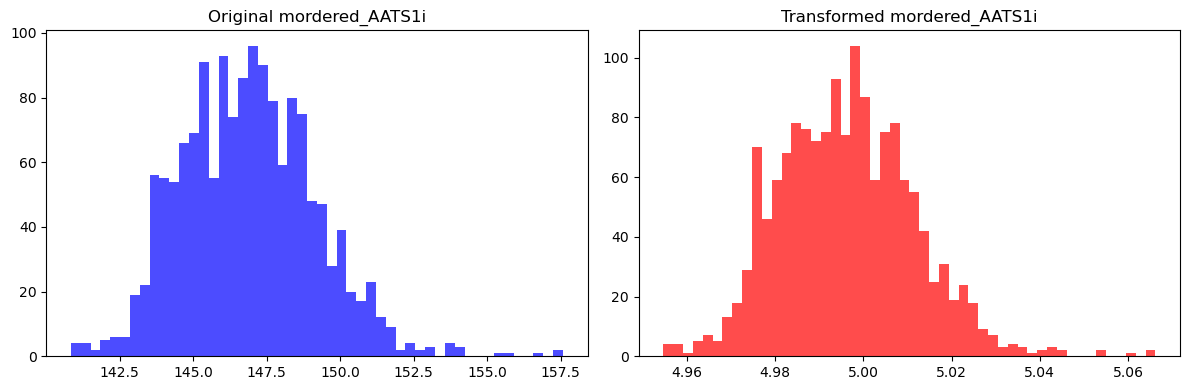

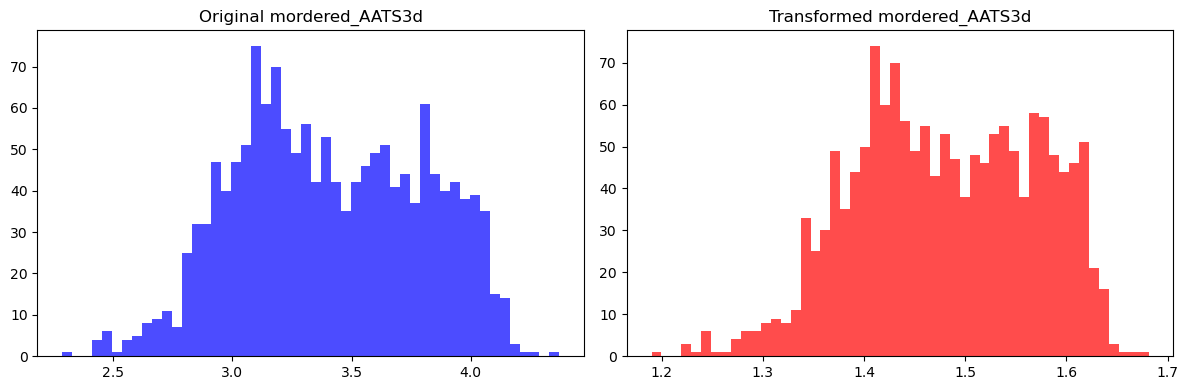

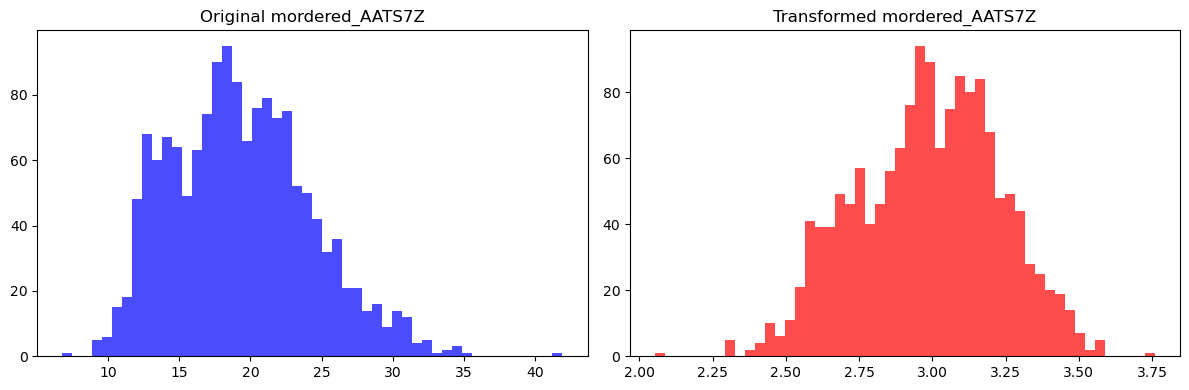

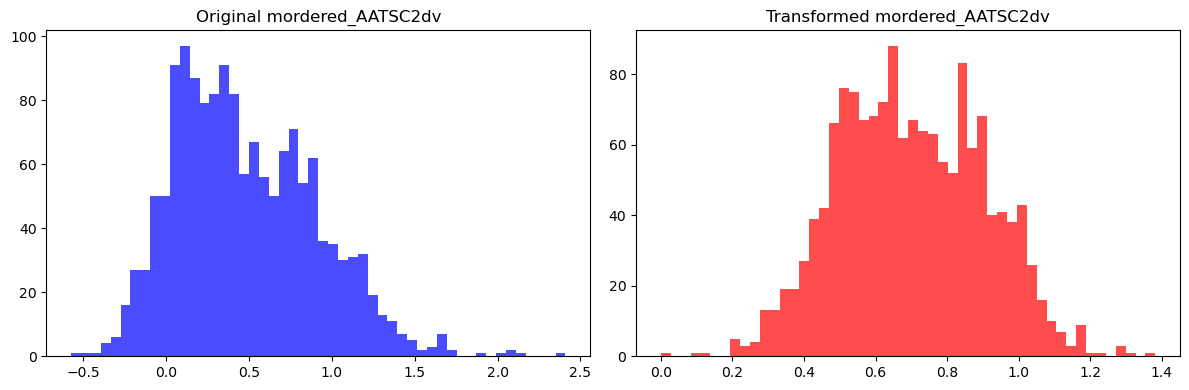

In [196]:
"""screen_df = df_herbal[FEATURES]
X_screen_transformed = preprocessor.transform(screen_df)


X_screen_log = pd.DataFrame(
    X_screen_transformed, 
    columns=transformed_columns, 
    index=screen_df.index
)"""


"""df_combine_log = pd.concat([X_train_log, X_screen_log], axis=0)

def plot_transformation(original, transformed, col_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.hist(original, bins=50, color='blue', alpha=0.7)
    ax1.set_title(f'Original {col_name}')
    
    ax2.hist(transformed, bins=50, color='red', alpha=0.7)
    ax2.set_title(f'Transformed {col_name}')
    
    plt.tight_layout()
    plt.show()

# Plot first 3 transformed features
for idx, col in enumerate(non_binary_columns[:4]):
    plot_transformation(
        train_df[col].values, 
        X_train_log[col].values, 
        col
    )"""

In [145]:
"""df_combine_log.reset_index(drop=True, inplace=True)"""

In [33]:
df_herbal['class'] = ['herbal' for _ in range(len(df_herbal))]
df_herbal['target'] = ['unkhown' for _ in range(len(df_herbal))]

df_herbal_filter_str = pd.concat([df_herbal[['name', 'smiles', 'dataset', 'class', 'target']], df_herbal[FEATURES]], axis=1)

In [125]:
df_herbal_filter_str = df_herbal_filter_str.dropna(axis=0).reset_index(drop=True)

model.predict_proba(df_herbal_filter_str[FEATURES].values)[:,1]



array([0.34723052, 0.38511098, 0.38987182, ..., 0.51005417, 0.4128921 ,
       0.48065076])

In [126]:
model.predict(df_herbal_filter_str[FEATURES].values).sum()

12933

In [127]:
df_herbal_filter_str['target'] = model.predict_proba(df_herbal_filter_str[FEATURES].values)[:,1]

In [128]:
df_herbal_filter_str['target']

0         0.347231
1         0.385111
2         0.389872
3         0.440866
4         0.324185
            ...   
122449    0.469687
122450    0.556610
122451    0.510054
122452    0.412892
122453    0.480651
Name: target, Length: 122454, dtype: float64

In [129]:
df_herbal_filter_str.rename(columns={'name':"molecule_chembl_id"}, inplace=True)

## metric for model 

In [28]:
param = {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 12,
         'max_features': "sqrt", 'min_samples_leaf':3, 'min_samples_split': 7,
         'n_estimators':150, 'random_state': 42}

In [29]:
model_str = RandomForestClassifier(**param)
FEATURES = fillter_f_dataset_str.columns.difference(['molecule_chembl_id', 'smiles', 'class', 'dataset', 'target'])
X_train_str = fillter_f_dataset_str.loc[fillter_f_dataset_str['dataset']=='train', FEATURES].values
y_train_str = fillter_f_dataset_str.loc[fillter_f_dataset_str['dataset']=='train', 'target'].values.astype(int)
X_test_str = fillter_f_dataset_str.loc[fillter_f_dataset_str['dataset']=='test', FEATURES].values
y_test_str = fillter_f_dataset_str.loc[fillter_f_dataset_str['dataset']=='test', 'target'].values.astype(int)

In [30]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    balanced_accuracy_score, 
    matthews_corrcoef, 
    precision_score, 
    recall_score, 
    roc_auc_score, 
    f1_score,
    make_scorer
)
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

def evaluate_model_with_cv(model, X, y, cv=5):
    """
    مدل را با استفاده از Stratified Cross Validation ارزیابی می‌کند
    
    Parameters:
    -----------
    model : sklearn estimator
        مدل برای ارزیابی
    X : array-like
        ویژگی‌ها
    y : array-like
        برچسب‌ها
    cv : int
        تعداد fold ها برای cross validation
    
    Returns:
    --------
    dict : نتایج ارزیابی
    """
    
    # تعریف scoring metrics
    scoring = {
        'balanced_accuracy': make_scorer(balanced_accuracy_score),
        'mcc': make_scorer(matthews_corrcoef),
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'roc_auc': make_scorer(roc_auc_score),
        'f1_score': make_scorer(f1_score)
    }
    
    # ایجاد StratifiedKFold
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    # انجام cross validation
    cv_results = cross_validate(
        model, X, y, 
        cv=skf, 
        scoring=scoring, 
        return_train_score=False,
        n_jobs=-1
    )
    
    # محاسبه میانگین و انحراف معیار
    results = {}
    for metric in scoring.keys():
        test_scores = cv_results[f'test_{metric}']
        results[metric] = {
            'mean': np.mean(test_scores),
            'std': np.std(test_scores),
            'scores': test_scores
        }
    
    return results

def print_cv_results(results):
    """
    نتایج cross validation را به صورت مرتب چاپ می‌کند
    """
    print("=" * 60)
    print("نتایج Stratified Cross Validation (CV=5)")
    print("=" * 60)
    
    metrics_names = {
        'balanced_accuracy': 'Balanced Accuracy',
        'mcc': 'Matthews Correlation Coefficient (MCC)',
        'precision': 'Precision',
        'recall': 'Recall',
        'roc_auc': 'AUC-ROC',
        'f1_score': 'F1-Score'
    }
    
    for metric, name in metrics_names.items():
        mean_score = results[metric]['mean']
        std_score = results[metric]['std']
        print(f"{name:35}: {mean_score:.4f} ± {std_score:.4f}")
    
    print("=" * 60)



In [31]:
results = evaluate_model_with_cv(model_str, X_train_str, y_train_str, cv=5)
print_cv_results(results)

نتایج Stratified Cross Validation (CV=5)
Balanced Accuracy                  : 0.8077 ± 0.0203
Matthews Correlation Coefficient (MCC): 0.6200 ± 0.0399
Precision                          : 0.7725 ± 0.0392
Recall                             : 0.7515 ± 0.0441
AUC-ROC                            : 0.8077 ± 0.0203
F1-Score                           : 0.7604 ± 0.0253


In [32]:
model_str.fit(X_train_str, y_train_str)


RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=3, min_samples_split=7,
                       n_estimators=150, random_state=42)

In [33]:
y_pred = model_str.predict(X_test_str)
mcc = matthews_corrcoef(y_test_str, y_pred)
fscore = f1_score(y_test_str, y_pred, average='binary')
b_acc = balanced_accuracy_score(y_test_str, y_pred)
pre = precision_score(y_test_str, y_pred, average='binary')
reca = recall_score(y_test_str, y_pred, average='binary')